In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv('../data/q2_customers.csv')

# Display basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("\nScaled Data Sample:")
print(X_scaled.head())

Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Scaled Data Sample:
        age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150    

## Task 1: Data Preparation

The dataset contains 500 customer records with 6 features and no missing values. All features are numerical, making it ready for scaling.

**Why scaling is essential before K-Means:**

K-Means calculates distances between data points to form clusters. If features have different scales (e.g. `annual_spend` ranges in tens of thousands while `visits_per_month` ranges from 1-20), the algorithm will be dominated by the high-magnitude features. StandardScaler transforms each feature to have mean=0 and standard deviation=1, ensuring every feature contributes equally to the distance calculation.

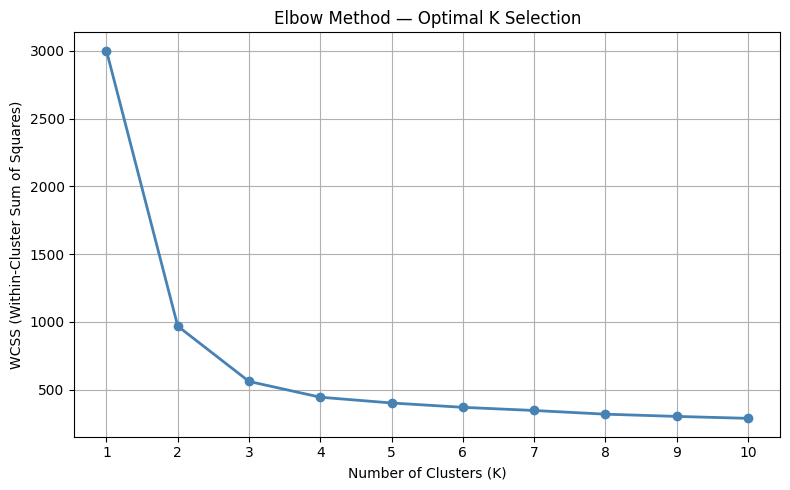

WCSS values: [3000.0000000000005, 968.993871407486, 561.2530064181283, 444.9302757372017, 402.3713031925936, 370.3853930716351, 346.95408078731265, 319.8974753699748, 303.28225021542653, 289.11397854105826]


In [12]:
# Task 2: Elbow Method to find optimal K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()

print("WCSS values:", wcss)

## Task 2: Choosing K — Elbow Method

The WCSS drops steeply from K=1 to K=3, after which the rate of decrease slows significantly and the curve flattens. This "elbow" point at **K=3** indicates the optimal number of clusters — adding more clusters beyond 3 yields diminishing returns in terms of reducing within-cluster variance.

**Selected K = 3**

In [13]:
# Task 3: K-Means Clustering with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = kmeans.labels_

# Print cluster centroids in readable format
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                         columns=df.columns[:-1])
centroids.index.name = 'Cluster'
print("Cluster Centroids (in original scale):")
print(centroids.round(2))

# Cluster sizes
print("\nCluster Sizes:")
print(df['cluster'].value_counts().sort_index())

Cluster Centroids (in original scale):
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  

Cluster Sizes:
cluster
0    170
1    165
2    165
Name: count, dtype: int64


## Task 3: K-Means Clustering

K-Means was fitted with K=3. The three clusters are roughly equal in size (170, 165, 165).

**Cluster Interpretations:**

- **Cluster 0 — Young Frequent Browsers:** Average age 25, low annual spend (£14,847), high visit frequency (14x/month), shops recently (9 days ago). These are young, engaged but low-spending customers — potential targets for upselling promotions.

- **Cluster 1 — High-Value Dormant Customers:** Average age 57, very high annual spend (£89,413), very infrequent visits (2.5x/month), last visited 105 days ago. These are valuable but at-risk customers — win-back campaigns are recommended.

- **Cluster 2 — Regular Mid-Spenders:** Average age 40, moderate spend (£43,341), moderate visits (8x/month). These are the most consistent and reliable customer segment.

In [14]:
# Task 4: PCA - Reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)
print("\nFeature Loadings:")
print(loadings.round(4))

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 89.13%

Feature Loadings:
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


## Task 4: Dimensionality Reduction with PCA

**Explained Variance:**
- PC1 captures 83.56% of the total variance
- PC2 captures 5.57% of the total variance
- Together they explain 89.13% of the data — sufficient for visualisation

**Interpretation of Components:**

**PC1 — Overall Customer Value Axis:**
PC1 has high positive loadings on `age` (0.41), `annual_spend` (0.42), `basket_size` (0.41), `days_since_last_visit` (0.38), and `num_categories_purchased` (0.41), with a negative loading on `visits_per_month` (-0.41). This means PC1 separates older, high-spending, infrequent customers (high PC1) from younger, frequent, low-spending customers (low PC1).

**PC2 — Recency Axis:**
PC2 is dominated by `days_since_last_visit` (0.91), meaning it primarily captures how recently a customer last visited. High PC2 = dormant customers; Low PC2 = recently active customers.

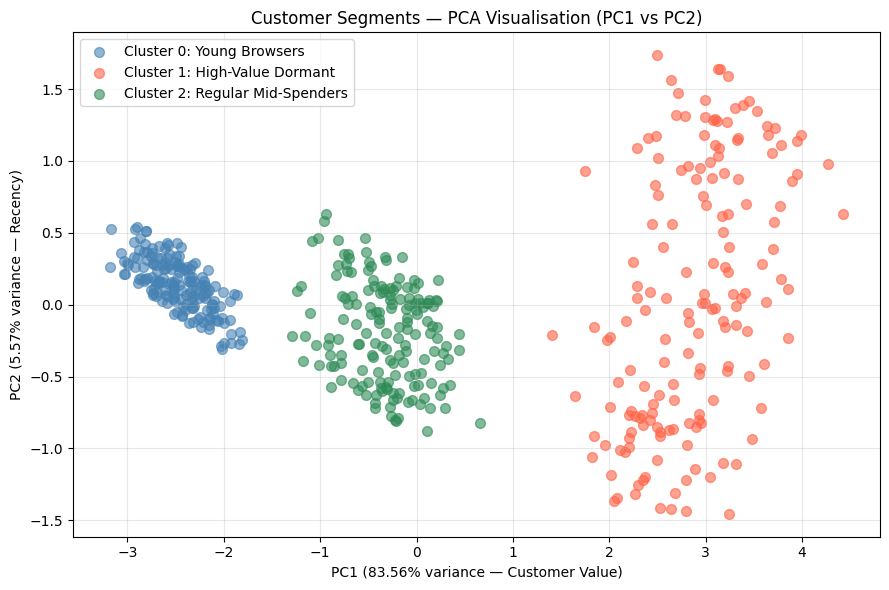

In [15]:
# Task 5: Scatter plot of PC1 vs PC2 coloured by cluster
plt.figure(figsize=(9, 6))

colors = ['steelblue', 'tomato', 'seagreen']
cluster_names = ['Cluster 0: Young Browsers', 'Cluster 1: High-Value Dormant', 'Cluster 2: Regular Mid-Spenders']

for cluster in range(3):
    mask = df['cluster'] == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cluster],
        label=cluster_names[cluster],
        alpha=0.6,
        s=50
    )

plt.title('Customer Segments — PCA Visualisation (PC1 vs PC2)')
plt.xlabel('PC1 (83.56% variance — Customer Value)')
plt.ylabel('PC2 (5.57% variance — Recency)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 5: Cluster Visualisation

The PCA scatter plot shows three well-separated customer clusters along PC1 (Customer Value axis):

- **Blue (Cluster 0 — Young Browsers):** Grouped on the left (low PC1), confirming low customer value and high visit frequency.
- **Green (Cluster 2 — Regular Mid-Spenders):** Positioned in the middle, representing average value customers.
- **Red (Cluster 1 — High-Value Dormant):** Spread on the right (high PC1), confirming high spend but also high days since last visit (spread along PC2).

The clear separation validates that K=3 was the correct choice and that the clusters are meaningful and distinct.